# Specific Task 2.4 Train/Evaluate advanced model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Reading Data

In [2]:
def read_txt(path):
    rows = []
    with open(path, "r", encoding="utf-8") as fh:
        lines = fh.read().splitlines()
    for line in lines:
        parts = line.split(": ")
        if len(parts) < 4:
            continue
        rows.append({
            "Event Type": parts[0].strip(),
            "Interaction": parts[1].strip(),
            "Feynman Diagram": parts[2].strip(),
            "Amplitude": parts[-2].strip(),
            "Squared Amplitude": parts[-1].strip()
        })
    return rows

In [3]:
base_dir = "/kaggle/input/datasets/arnavtripathi01/symba-test-data/SYMBA - Test Data"

qed_data = []
qcd_data = []

for file in os.listdir(base_dir):
    path = os.path.join(base_dir, file)
    rows = read_txt(path)
    if "QED" in file:
        qed_data.extend(rows)
    if "QCD" in file:
        qcd_data.extend(rows)

In [4]:
qed_df = pd.DataFrame(qed_data)
qcd_df = pd.DataFrame(qcd_data)

print("QED dataset size:", len(qed_df))
print("QCD dataset size:", len(qcd_df))

QED dataset size: 360
QCD dataset size: 234


# Train-Val-Test Split

In [5]:
from sklearn.model_selection import train_test_split

# split QED
qed_train, temp_df = train_test_split(qed_df, test_size=0.2, random_state=42, shuffle=True)
qed_val, qed_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

# split QCD
qcd_train, temp_df = train_test_split(qcd_df, test_size=0.2, random_state=42, shuffle=True)
qcd_val, qcd_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

print(f"QED -> Train size : {len(qed_train)}, Validation size : {len(qed_val)}, Test size : {len(qed_test)}")
print(f"QCD -> Train size : {len(qcd_train)}, Validation size : {len(qcd_val)}, Test size : {len(qcd_test)}")

qed_train.to_csv("qed_train.csv")
qed_val.to_csv("qed_val.csv")
qed_test.to_csv("qed_test.csv")

qcd_train.to_csv("qcd_train.csv")
qcd_val.to_csv("qcd_val.csv")
qcd_test.to_csv("qcd_test.csv")

QED -> Train size : 288, Validation size : 36, Test size : 36
QCD -> Train size : 187, Validation size : 23, Test size : 24


# Tokenizer

In [6]:
import json
from collections import Counter, OrderedDict
import re
import unicodedata
import warnings
from typing import List, Tuple, Dict, Any
from tqdm.auto import tqdm

class PittTokenizer:
    """Physics-informed tokenizer for amplitudes and squared amplitudes expressions."""
    def __init__(
        self,
        index_token_pool_size = 120,
        momentum_token_pool_size = 10,
        particle_index_pool_size = 10,
        special_symbols = None,
        unk_idx = 3
    ):
        self.index_pool_size = int(index_token_pool_size)
        self.momentum_pool_size = int(momentum_token_pool_size)
        self.particle_index_pool_size = int(particle_index_pool_size)
        self.index_tokens = [f"INDEX_{i}" for i in range(self.index_pool_size)]
        self.momentum_tokens = [f"MOMENTUM_{i}" for i in range(self.momentum_pool_size)]
        self.pindex_tokens = [f"PINDEX_{i}" for i in range(self.particle_index_pool_size)]
        self.special_symbols = special_symbols or ["<BOS>", "<PAD>", "<EOS>", "<UNK>", "<SEP>"]
        self.unk_idx = unk_idx

        # regex patterns
        self._re_whitespace = re.compile(r"\s+")
        self._re_unicode_norm = unicodedata.normalize
        self._re_gamma_token = re.compile(r'gamma_\{([^}]+)\}')
        self._re_wavefunction = re.compile(r'\b([A-Za-z]+)_\{([^}]+)\}\(([^)]+)\)(_[A-Za-z]+)(\^CONJ)?')
        self._re_momentum = re.compile(r'\bp_(\d+)\b')
        self._re_mandelstam = re.compile(r'\bs_(\d+)\b')
        self._re_mass = re.compile(r'\bm_[A-Za-z]+\b')
        self._re_particle_index = re.compile(r'\b([ijkl])_(\d+)\b')
        # candidate indices excluding mass/momentum/mandelstam/particle indices
        self._re_index_candidate = re.compile(r'(?!p_)(?!s_)(?!m_)(?![ijkl]_)[A-Za-z%\\]+_\d+')
        # operators and separators
        self._operators = list('/+-*^,{}()[]:=') 

    # ---- Normalization Utilities ----
    def normalize_unicode_and_whitespace(self, expression):
        """Apply unicode normalization and collapse whitespace."""
        if expression is None:
            return ""
        expr = self._re_unicode_norm("NFKC", expression)
        expr = self._re_whitespace.sub(" ", expr).strip()
        return expr

    def fix_brace_spaces(self, expr):
        """Canonicalize spacing inside {...} blocks:"""
        def clean(match):
            inner = match.group(1)
            inner = inner.strip()
            inner = re.sub(r'\s*,\s*', ',', inner)
            inner = re.sub(r'\s*\+\s*', '+', inner)
            inner = re.sub(r'\s*-\s*', '-', inner)
            return '{' + inner + '}'
        return re.sub(r'\{([^}]*)\}', clean, expr)

    def preprocess_expression(self, expression):
        """Canonicalize common physics tokens and simple formatting."""
        expr = self.normalize_unicode_and_whitespace(str(expression))
        expr = expr.replace("me", "m_e")
        expr = expr.replace("reg_prop", "REG_PROP")
        expr = expr.replace("(*)", "CONJ")
        expr = expr.replace("+-", "-").replace("-+", "-")
        expr = re.sub(r'\s*\*\s*', '*', expr)
        expr = re.sub(r'\s*/\s*', '/', expr)
        expr = re.sub(r'\s*\^\s*', '^', expr)
        expr = re.sub(r'\s*\+\s*', ' + ', expr)
        expr = re.sub(r'\s*-\s*', ' - ', expr)
        expr = re.sub(r'\s+', ' ', expr).strip()
        expr = self.fix_brace_spaces(expr)
        return expr

    def physics_aware_replace(self, expr):
        """Canonicalize momentum, mandelstam, masses, conjugation, imaginary unit and constants."""
        e = expr
        e = self._re_mandelstam.sub(r"MANDELSTAM_\1", e)
        e = self._re_momentum.sub(r"P_\1", e)
        e = self._re_mass.sub(lambda m: m.group(0), e)
        e = re.sub(r'\bi\b(?!\w)', 'I_UNIT', e)
        e = re.sub(r'\be\b(?=\^|[+\-*/()| ,])', 'E_CHARGE', e)
        e = re.sub(r'\bg\b(?=\^|[+\-*/()| ,])', 'G_COUPLING', e)
        return e

    # ---- Index Normalisation and Mapping ----
    def extract_pair_index_order(self, amp, sqamp):
        """Return ordered unique candidate indices, particle indices and momentum matches for a pair."""
        combined = amp + " || " + sqamp
        # find regular index candidates
        seen = OrderedDict()
        for m in self._re_index_candidate.finditer(combined):
            key = m.group(0)
            if key not in seen:
                seen[key] = None
        index_candidates = list(seen.keys())
        # particle indices
        pseen = OrderedDict()
        for m in self._re_particle_index.finditer(combined):
            key = m.group(0)
            if key not in pseen:
                pseen[key] = None
        particle_candidates = list(pseen.keys())
        # momentum occurrences
        mseen = OrderedDict()
        for m in self._re_momentum.finditer(combined):
            key = m.group(0)
            if key not in mseen:
                mseen[key] = None
        momentum_candidates = list(mseen.keys())

        return index_candidates, particle_candidates, momentum_candidates

    def build_deterministic_mapping(self, index_candidates, particle_candidates, momentum_candidates):
        """Create deterministic mapping to INDEX_/PINDEX_/MOMENTUM_ tokens."""
        mapping = {}
        for i, old in enumerate(index_candidates):
            if i >= self.index_pool_size:
                raise RuntimeError("index_pool exhausted; increase index_token_pool_size")
            mapping[old] = self.index_tokens[i]
        for i, old in enumerate(particle_candidates):
            if i >= self.particle_index_pool_size:
                raise RuntimeError("particle_index_pool exhausted; increase particle_index_pool_size")
            mapping[old] = self.pindex_tokens[i]
        for i, old in enumerate(momentum_candidates):
            if i >= self.momentum_pool_size:
                raise RuntimeError("momentum_pool exhausted; increase momentum_token_pool_size")
            mapping[old] = self.momentum_tokens[i]
        return mapping

    def apply_mapping_to_text(self, text, mapping):
        """Replace all full-token matches in text using provided mapping."""
        if not mapping:
            return text
        for old in sorted(mapping.keys(), key=len, reverse=True):
            new = mapping[old]
            text = text.replace(old, new)
        return text

    def normalize_pair_indices(self, ampl, sqamp):
        """Pre-processes and returns strictly mapped strings."""
        amp_p = self.preprocess_expression(ampl)
        sqamp_p = self.preprocess_expression(sqamp)
        idx_cands, p_cands, m_cands = self.extract_pair_index_order(amp_p, sqamp_p)
        mapping = self.build_deterministic_mapping(idx_cands, p_cands, m_cands)
        amp_mapped = self.apply_mapping_to_text(amp_p, mapping)
        sqamp_mapped = self.apply_mapping_to_text(sqamp_p, mapping)
        amp_final = self.physics_aware_replace(amp_mapped)
        sqamp_final = self.physics_aware_replace(sqamp_mapped)
        amp_final = self.fix_brace_spaces(amp_final)
        sqamp_final = self.fix_brace_spaces(sqamp_final)
        return amp_final, sqamp_final, mapping

    def normalize_dataframe_pairs(self, df, keep_mapping=False):
            """Applies normalization to dataframes."""
            records = []
            for _, row in tqdm(df.iterrows(), total=len(df), desc="Normalizing DataFrame Pairs"):
                ampl = row.get("Amplitude", "")
                sqamp = row.get("Squared Amplitude", "")
                ampl_norm, sqamp_norm, mapping = self.normalize_pair_indices(ampl, sqamp)
                rec = row.to_dict()
                rec["Amplitude_norm"] = ampl_norm
                rec["Squared_Amplitude_norm"] = sqamp_norm
                if keep_mapping:
                    rec["index_mapping"] = json.dumps(mapping)
                records.append(rec)
            return pd.DataFrame.from_records(records)
    
    # ---- Splitting Tokens ----
    def expand_structured_tokens(self, text):
        """Expand structured physics tokens by splitting their index/momentum arguments."""
        def _expand_gamma(m):
            inner = m.group(1)
            parts = [p.strip() for p in inner.split(',')]
            return f"GAMMA_{len(parts)} " + " , ".join(parts)
    
        def _expand_wavefunction(m):
            name  = m.group(1).upper()
            inner = m.group(2)
            mom   = m.group(3)
            vtype = m.group(4)
            conj  = " CONJ" if m.group(5) else ""
            parts = [p.strip() for p in inner.split(',')]
            return f"{name}_{len(parts)} " + " , ".join(parts) + f" {mom} {vtype}{conj}"
    
        text = self._re_wavefunction.sub(_expand_wavefunction, text)
        text = self._re_gamma_token.sub(_expand_gamma, text)
        text = re.sub(r'(MOMENTUM_\d+)_(INDEX_\d+)', r'\1 \2', text)
        return text
        
    def split_tokens(self, text):
        """Split on operators and keep tokens intelligible to transformer."""
        t = text
        for op in self._operators:
            t = t.replace(op, f' {op} ')
        # more frequent fractions kept intact
        top_fracs = ["1/2", "1/16", "1/9", "4/9", "1/448", "16/7", "1/144", "1/3", "1/6", "8/7"]
        for f in top_fracs:
            t = re.sub(rf"\b{f.replace('/', ' / ')}\b", f, t)
        t = re.sub(r'\s+', ' ', t).strip()
        tokens = [tok for tok in t.split(' ') if tok]
        return tokens

    def src_tokenize(self, ampl_norm):
        """Tokenize Source expression."""
        if not ampl_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(ampl_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Source tokenization failed for '{ampl_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    def tgt_tokenize(self, sqamp_norm):
        """Tokenize Target expression."""
        if not sqamp_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(sqamp_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Target tokenization failed for '{sqamp_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    # ---- Build Vocabularies ----
    def get_base_vocab(self):
        """Returns a set of index, momentum and pindex tokens."""
        base = set(self.special_symbols)
        base.update(self.index_tokens)
        base.update(self.momentum_tokens)
        base.update(self.pindex_tokens)
        return base

    def build_src_vocab(self, df: pd.DataFrame) -> set:
        """Build Source Vocabulary."""
        src_vocab = self.get_base_vocab()
        for s in tqdm(df["Amplitude_norm"].astype(str), total=len(df), desc="Building src vocab"):
            src_vocab.update(self.src_tokenize(s))
        return src_vocab

    def build_tgt_vocab(self, df: pd.DataFrame) -> set:
        """Build Target Vocabulary."""
        tgt_vocab = self.get_base_vocab()
        for s in tqdm(df["Squared_Amplitude_norm"].astype(str), total=len(df), desc="Building tgt vocab"):
            tgt_vocab.update(self.tgt_tokenize(s))
        return tgt_vocab

    def save_vocab(self, path, src_vocab, tgt_vocab):
        """Save Vocabularies to JSON file."""
        out = {
            "special_symbols": self.special_symbols,
            "src_vocab": sorted(list(src_vocab)),
            "tgt_vocab": sorted(list(tgt_vocab))
        }
        with open(path, "w", encoding="utf-8") as fh:
            json.dump(out, fh, ensure_ascii=False, indent=2)

    def load_vocab(self, path):
        """Load Vocabularies from JSON file."""
        with open(path, "r", encoding="utf-8") as fh:
            return json.load(fh)

In [7]:
class SymbolicVocab:
    """Simple vocab mapping between tokens and indices."""
    def __init__(self, tokens, special_symbols):
        remaining_tokens = sorted(list(set(tokens) - set(special_symbols)))
        self.token_list = special_symbols + remaining_tokens
        self.token_to_idx = {tok: i for i, tok in enumerate(self.token_list)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}
        self.bos_idx = self.token_to_idx.get("<BOS>", 0)
        self.pad_idx = self.token_to_idx.get("<PAD>", 1)
        self.eos_idx = self.token_to_idx.get("<EOS>", 2)
        self.unk_idx = self.token_to_idx.get("<UNK>", 3)
        self.sep_idx = self.token_to_idx.get("<SEP>", 4)
        
    def encode(self, tokens):
        return [self.token_to_idx.get(tok, self.unk_idx) for tok in tokens]

    def decode(self, indices, include_special_tokens = True):
        if include_special_tokens:
            return [self.idx_to_token.get(i, "<UNK>") for i in indices]
        
        specials = {self.pad_idx, self.bos_idx, self.eos_idx, self.sep_idx}
        return [self.idx_to_token.get(i, "<UNK>") for i in indices if i not in specials]

    def __len__(self):
        return len(self.token_list)

# Architecture

In [8]:
import os, re, json, math, unicodedata, warnings
from collections import OrderedDict
from dataclasses import dataclass, asdict
from functools import partial
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [9]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass, asdict
from typing import Optional, List

# Config
@dataclass
class Config:
    vocab_size:   int
    dim:          int   = 256
    heads:        int   = 8
    enc_depth:    int   = 3
    dec_depth:    int   = 3
    ff_expansion: float = 4.0
    dropout:      float = 0.1
    pad_idx:      int   = 1
    tie_weights:  bool  = False

    def __post_init__(self):
        assert self.dim % self.heads == 0, 'dim must be divisible by heads'
    def to_dict(self): return asdict(self)

# Sinusoidal Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout = 0.1, max_len = 2048):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10_000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.drop(x + self.pe[:, :x.size(1)])

# Multi-Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout = 0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.h  = n_heads
        self.dk = d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
        self.drop = dropout

    def _split(self, t):
        B, S, _ = t.shape
        return t.view(B, S, self.h, self.dk).transpose(1, 2)

    def forward(self, q, k, v, key_padding_mask = None, is_causal = False):
        B, Sq, _ = q.shape
        Sk = k.size(1)

        Q = self._split(self.Wq(q))
        K = self._split(self.Wk(k))
        V = self._split(self.Wv(v))

        attn_mask: Optional[torch.Tensor] = None

        if is_causal:
            causal = torch.zeros(Sq, Sk, device=q.device, dtype=q.dtype)
            causal.masked_fill_(
                torch.ones(Sq, Sk, device=q.device, dtype=torch.bool).triu(diagonal=1),
                float('-inf'),
            )
            attn_mask = causal

        if key_padding_mask is not None:
            pad = torch.zeros(B, 1, 1, Sk, device=q.device, dtype=q.dtype)
            pad.masked_fill_(key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf'))
            attn_mask = pad if attn_mask is None else attn_mask + pad

        out = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=attn_mask,
            dropout_p=self.drop if self.training else 0.0,
        )
        return self.Wo(out.transpose(1, 2).reshape(B, Sq, self.h * self.dk))

# Feed-Forward
class FeedForward(nn.Module):
    def __init__(self, d_model, expansion = 4.0, dropout = 0.0):
        super().__init__()
        hidden = int(d_model * expansion)
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# Encoder Layer
class EncoderLayer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn  = MultiHeadAttention(cfg.dim, cfg.heads, cfg.dropout)
        self.norm1 = nn.LayerNorm(cfg.dim)
        self.ff    = FeedForward(cfg.dim, cfg.ff_expansion, cfg.dropout)
        self.norm2 = nn.LayerNorm(cfg.dim)

    def forward(self, x, src_pad_mask = None):
        x = self.norm1(x + self.attn(x, x, x, key_padding_mask=src_pad_mask))
        x = self.norm2(x + self.ff(x))
        return x

# Encoder
class Encoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embed  = nn.Embedding(cfg.vocab_size, cfg.dim, padding_idx=cfg.pad_idx)
        self.pe     = PositionalEncoding(cfg.dim, cfg.dropout)
        self.layers = nn.ModuleList([EncoderLayer(cfg) for _ in range(cfg.enc_depth)])
        self.scale  = math.sqrt(cfg.dim)
        nn.init.normal_(self.embed.weight, std=0.02)
        with torch.no_grad():
            self.embed.weight[cfg.pad_idx].fill_(0)

    def forward(self, src_ids, src_mask = None):
        src_pad_mask = ~src_mask if src_mask is not None else None
        x = self.pe(self.embed(src_ids) * self.scale)
        for layer in self.layers:
            x = layer(x, src_pad_mask=src_pad_mask)
        return x

# Decoder Layer
class DecoderLayer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.self_attn  = MultiHeadAttention(cfg.dim, cfg.heads, cfg.dropout)
        self.norm1      = nn.LayerNorm(cfg.dim)
        self.cross_attn = MultiHeadAttention(cfg.dim, cfg.heads, cfg.dropout)
        self.norm2      = nn.LayerNorm(cfg.dim)
        self.ff         = FeedForward(cfg.dim, cfg.ff_expansion, cfg.dropout)
        self.norm3      = nn.LayerNorm(cfg.dim)

    def forward(self, x, enc_out, enc_pad_mask = None):
        x = self.norm1(x + self.self_attn(x, x, x, is_causal=True))
        x = self.norm2(x + self.cross_attn(x, enc_out, enc_out, key_padding_mask=enc_pad_mask))
        x = self.norm3(x + self.ff(x))
        return x

# Decoder
class Decoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.embed   = nn.Embedding(cfg.vocab_size, cfg.dim, padding_idx=cfg.pad_idx)
        self.pe      = PositionalEncoding(cfg.dim, cfg.dropout)
        self.layers  = nn.ModuleList([DecoderLayer(cfg) for _ in range(cfg.dec_depth)])
        self.norm    = nn.LayerNorm(cfg.dim)
        self.lm_head = nn.Linear(cfg.dim, cfg.vocab_size, bias=False)
        self.scale   = math.sqrt(cfg.dim)
        nn.init.normal_(self.embed.weight, std=0.02)

    def forward(self, tgt_ids, enc_out, enc_pad_mask = None):
        x = self.pe(self.embed(tgt_ids) * self.scale)
        for layer in self.layers:
            x = layer(x, enc_out, enc_pad_mask=enc_pad_mask)
        return self.lm_head(self.norm(x))

# Transformer
class Transformer(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg     = cfg
        self.encoder = Encoder(cfg)
        self.decoder = Decoder(cfg)
        if cfg.tie_weights:
            self.decoder.embed.weight   = self.encoder.embed.weight
            self.decoder.lm_head.weight = self.decoder.embed.weight

    def forward(self, src_ids, tgt_ids, labels = None, src_mask = None):
        src_pad_mask = ~src_mask if src_mask is not None else None
        enc_out = self.encoder(src_ids, src_mask=src_mask)
        logits  = self.decoder(tgt_ids, enc_out, enc_pad_mask=src_pad_mask)

        if labels is None:
            return logits

        return F.cross_entropy(
            logits.reshape(-1, self.cfg.vocab_size),
            labels.reshape(-1),
            ignore_index=self.cfg.pad_idx,
        )

    @torch.no_grad()
    def greedy_generate(self, src_ids, bos_idx, max_new_tokens = 2024,
                        eos_idx = None, device=None, tgt_logit_mask = None):
        self.eval()
        device = device or next(self.parameters()).device

        if not torch.is_tensor(src_ids):
            src_ids = torch.tensor(src_ids, dtype=torch.long)
        if src_ids.dim() == 1:
            src_ids = src_ids.unsqueeze(0)
        src_ids = src_ids.to(device)
        B = src_ids.shape[0]

        src_mask     = (src_ids != self.cfg.pad_idx)
        src_pad_mask = ~src_mask
        enc_out      = self.encoder(src_ids, src_mask=src_mask)

        ys         = torch.full((B, 1), bos_idx, dtype=torch.long, device=device)
        unfinished = torch.ones(B, dtype=torch.bool, device=device)

        for _ in range(max_new_tokens):
            logits      = self.decoder(ys, enc_out, enc_pad_mask=src_pad_mask)
            next_logits = logits[:, -1]

            if tgt_logit_mask is not None:
                next_logits = next_logits + tgt_logit_mask.to(device)

            next_tok = next_logits.argmax(-1, keepdim=True)

            inp = next_tok.clone()
            inp[~unfinished] = self.cfg.pad_idx
            ys = torch.cat([ys, inp], dim=1)

            if eos_idx is not None:
                unfinished = unfinished & (next_tok.squeeze(1) != eos_idx)
                if not unfinished.any():
                    break

        results = []
        for b in range(B):
            toks = ys[b, 1:].tolist()
            if eos_idx is not None and eos_idx in toks:
                toks = toks[:toks.index(eos_idx) + 1]
            results.append(toks)
        return results

    def save(self, path, optimizer=None, scheduler=None, history=None):
        payload = {'model': self.state_dict(), 'config': self.cfg.to_dict()}
        if optimizer:  payload['optimizer'] = optimizer.state_dict()
        if scheduler:  payload['scheduler'] = scheduler.state_dict()
        if history:    payload['history']   = history
        torch.save(payload, path)

    def save_artifacts(self, run_dir, vocab, tok, optimizer=None, scheduler=None, history=None):
        import os, json
        os.makedirs(run_dir, exist_ok=True)
        self.save(os.path.join(run_dir, 'model.pt'), optimizer, scheduler, history)
        vocab_payload = {
            'token_list': vocab.token_list,
            'bos_idx': vocab.bos_idx, 'pad_idx': vocab.pad_idx,
            'eos_idx': vocab.eos_idx, 'unk_idx': vocab.unk_idx,
        }
        with open(os.path.join(run_dir, 'vocab.json'), 'w') as f:
            json.dump(vocab_payload, f, ensure_ascii=False, indent=2)
        tok_cfg = {
            'index_pool':    tok.index_pool_size,
            'momentum_pool': tok.momentum_pool_size,
            'pindex_pool':   tok.particle_index_pool_size,
            'special_symbols': tok.special_symbols,
        }
        with open(os.path.join(run_dir, 'tok_config.json'), 'w') as f:
            json.dump(tok_cfg, f, indent=2)

    @classmethod
    def load(cls, path, device='cpu'):
        ckpt  = torch.load(path, map_location=device)
        model = cls(Config(**ckpt['config']))
        model.load_state_dict(ckpt['model'])
        return model, ckpt

    @classmethod
    def load_artifacts(cls, run_dir, device='cpu'):
        import os, json
        model, ckpt = cls.load(os.path.join(run_dir, 'model.pt'), device=device)
        with open(os.path.join(run_dir, 'vocab.json')) as f:
            vd = json.load(f)
        vocab = SymbolicVocab.__new__(SymbolicVocab)
        vocab.token_list   = vd['token_list']
        vocab.token_to_idx = {t: i for i, t in enumerate(vocab.token_list)}
        vocab.idx_to_token = {i: t for t, i in vocab.token_to_idx.items()}
        vocab.bos_idx = vd['bos_idx']; vocab.pad_idx = vd['pad_idx']
        vocab.eos_idx = vd['eos_idx']; vocab.unk_idx = vd['unk_idx']
        vocab.sep_idx = vocab.token_to_idx.get('<SEP>', 4)
        with open(os.path.join(run_dir, 'tok_config.json')) as f:
            tc = json.load(f)
        tok = PittTokenizer(
            index_token_pool_size=tc['index_pool'],
            momentum_token_pool_size=tc['momentum_pool'],
            particle_index_pool_size=tc['pindex_pool'],
            special_symbols=tc['special_symbols'],
        )
        return model, vocab, tok, ckpt

# Dataset & DataLoader

In [10]:
class SymbaDataset(Dataset):
    def __init__(self, df, tok: PittTokenizer, vocab,
                 max_src=2024, max_tgt=2024):
        df = tok.normalize_dataframe_pairs(df)
        self.samples = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc='Encoding'):
            st = tok.src_tokenize(row['Amplitude_norm'])
            tt = tok.tgt_tokenize(row['Squared_Amplitude_norm'])
            src   = [vocab.bos_idx] + vocab.encode(st)[:max_src-2] + [vocab.eos_idx]
            tgt   = [vocab.bos_idx] + vocab.encode(tt)[:max_tgt-1]
            label = vocab.encode(tt)[:max_tgt-1] + [vocab.eos_idx]
            self.samples.append((src, tgt, label))

    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


def collate(batch, pad):
    srcs, tgts, lbls = zip(*batch)
    def _pad(seqs):
        ml = max(len(s) for s in seqs)
        return torch.tensor([[*s, *[pad]*(ml-len(s))] for s in seqs], dtype=torch.long)
    src_ids  = _pad(srcs)
    tgt_ids  = _pad(tgts)
    labels   = _pad(lbls)
    src_mask = (src_ids != pad)
    return src_ids, tgt_ids, labels, src_mask

# Setup

In [11]:
tok = PittTokenizer()

# Normalize both training sets to extract tokens
qed_train_n = tok.normalize_dataframe_pairs(qed_train)
qcd_train_n = tok.normalize_dataframe_pairs(qcd_train)

# Build vocab over BOTH datasets so both models share the same token space
qed_src_tokens = tok.build_src_vocab(qed_train_n)
qed_tgt_tokens = tok.build_tgt_vocab(qed_train_n)
qcd_src_tokens = tok.build_src_vocab(qcd_train_n)
qcd_tgt_tokens = tok.build_tgt_vocab(qcd_train_n)

all_tokens = qed_src_tokens | qed_tgt_tokens | qcd_src_tokens | qcd_tgt_tokens
vocab = SymbolicVocab(all_tokens, tok.special_symbols)

print(f'Shared vocab size: {len(vocab)}')
print(f'  QED src-only: {len(qed_src_tokens - qed_tgt_tokens)}')
print(f'  QED tgt-only: {len(qed_tgt_tokens - qed_src_tokens)}')
print(f'  QCD src-only: {len(qcd_src_tokens - qcd_tgt_tokens)}')
print(f'  QCD tgt-only: {len(qcd_tgt_tokens - qcd_src_tokens)}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Mask src-only tokens so the decoder never generates them during inference
_src_only_ids = [
    vocab.token_to_idx[t]
    for t in ((qed_src_tokens | qcd_src_tokens) - (qed_tgt_tokens | qcd_tgt_tokens))
    if t in vocab.token_to_idx
]
tgt_logit_mask = torch.zeros(len(vocab))
tgt_logit_mask[_src_only_ids] = float('-inf')

Normalizing DataFrame Pairs:   0%|          | 0/288 [00:00<?, ?it/s]

Normalizing DataFrame Pairs:   0%|          | 0/187 [00:00<?, ?it/s]

Building src vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Building tgt vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Building src vocab:   0%|          | 0/187 [00:00<?, ?it/s]

Building tgt vocab:   0%|          | 0/187 [00:00<?, ?it/s]

Shared vocab size: 248
  QED src-only: 22
  QED tgt-only: 12
  QCD src-only: 19
  QCD tgt-only: 40
Device: cuda


In [12]:
BATCH = 32
_col  = partial(collate, pad=vocab.pad_idx)

# QED loaders
train_ds_qed = SymbaDataset(qed_train, tok, vocab)
val_ds_qed   = SymbaDataset(qed_val,   tok, vocab)
test_ds_qed  = SymbaDataset(qed_test,  tok, vocab)

train_loader_qed = DataLoader(train_ds_qed, BATCH, shuffle=True,  collate_fn=_col, num_workers=0)
val_loader_qed   = DataLoader(val_ds_qed,   BATCH, shuffle=False, collate_fn=_col, num_workers=0)
test_loader_qed  = DataLoader(test_ds_qed,  BATCH, shuffle=False, collate_fn=_col, num_workers=0)

print(f'QED  -> Train batches: {len(train_loader_qed)}  Val: {len(val_loader_qed)}  Test: {len(test_loader_qed)}')

# QCD loaders
train_ds_qcd = SymbaDataset(qcd_train, tok, vocab)
val_ds_qcd   = SymbaDataset(qcd_val,   tok, vocab)
test_ds_qcd  = SymbaDataset(qcd_test,  tok, vocab)

train_loader_qcd = DataLoader(train_ds_qcd, BATCH, shuffle=True,  collate_fn=_col, num_workers=0)
val_loader_qcd   = DataLoader(val_ds_qcd,   BATCH, shuffle=False, collate_fn=_col, num_workers=0)
test_loader_qcd  = DataLoader(test_ds_qcd,  BATCH, shuffle=False, collate_fn=_col, num_workers=0)

print(f'QCD  -> Train batches: {len(train_loader_qcd)}  Val: {len(val_loader_qcd)}  Test: {len(test_loader_qcd)}')

Normalizing DataFrame Pairs:   0%|          | 0/288 [00:00<?, ?it/s]

Encoding:   0%|          | 0/288 [00:00<?, ?it/s]

Normalizing DataFrame Pairs:   0%|          | 0/36 [00:00<?, ?it/s]

Encoding:   0%|          | 0/36 [00:00<?, ?it/s]

Normalizing DataFrame Pairs:   0%|          | 0/36 [00:00<?, ?it/s]

...

Normalizing DataFrame Pairs:   0%|          | 0/23 [00:00<?, ?it/s]

Encoding:   0%|          | 0/23 [00:00<?, ?it/s]

Normalizing DataFrame Pairs:   0%|          | 0/24 [00:00<?, ?it/s]

Encoding:   0%|          | 0/24 [00:00<?, ?it/s]

QCD  -> Train batches: 6  Val: 1  Test: 1


# Training

In [13]:
def run_epoch(model, optimizer, loader, device, grad_clip=1.0, train=True):
    """Run one train or validation epoch. Returns mean loss."""
    model.train(train)
    total_loss = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt, lbl, mask in tqdm(loader, leave=False):
            src, tgt, lbl, mask = (t.to(device) for t in (src, tgt, lbl, mask))
            loss = model(src, tgt, labels=lbl, src_mask=mask)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)


def seq_acc_ar(model, vocab, loader, device, n_batches=20):
    """Evaluate sequence and token accuracy,"""
    model.eval()
    seq_correct = seq_total = 0
    tok_correct = tok_total = 0

    for i, (src, _, lbl, _) in enumerate(loader):
        if i >= n_batches:
            break
        src = src.to(device)
        # Autoregressive generation
        preds = model.greedy_generate(
            src,
            bos_idx=vocab.bos_idx,
            eos_idx=vocab.eos_idx,
            device=device,
        )

        for j in range(src.shape[0]):
            gold      = [t for t in lbl[j].tolist() if t != vocab.pad_idx]
            pred_toks = preds[j]  # BOS already stripped by greedy_generate

            if pred_toks == gold:
                seq_correct += 1
            seq_total += 1

            for p, g in zip(pred_toks, gold):
                if p == g:
                    tok_correct += 1
            tok_total += len(gold)

    return (
        seq_correct / seq_total if seq_total else 0.0,
        tok_correct / tok_total if tok_total else 0.0,
    )

# QED Baseline

In [18]:
qed_cfg = Config(
    vocab_size   = len(vocab),
    dim          = 256,       
    heads        = 4,  
    enc_depth    = 3,
    dec_depth    = 3,
    ff_expansion = 4.0,
    dropout      = 0.1,
    pad_idx      = vocab.pad_idx,
    tie_weights  = False,
)

model_qed = Transformer(qed_cfg).to(device)
print(f'QED Transformer parameters: {sum(p.numel() for p in model_qed.parameters()):,}')
print(f'QED Config: dim={qed_cfg.dim}, heads={qed_cfg.heads}, '
      f'enc_depth={qed_cfg.enc_depth}, dec_depth={qed_cfg.dec_depth}')

QED Transformer parameters: 5,711,360
QED Config: dim=256, heads=4, enc_depth=3, dec_depth=3


In [19]:
QED_EPOCHS    = 250
QED_GRAD_CLIP = 1.0
QED_PATIENCE  = 20
QED_MIN_DELTA = 1e-3
QED_RUN_DIR   = 'plain_qed_run'

qed_optimizer = torch.optim.AdamW(model_qed.parameters(), lr=3e-4, weight_decay=0.01)
qed_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(qed_optimizer, T_max=QED_EPOCHS)
qed_history   = {'train_loss': [], 'val_loss': []}

best_val_qed   = float('inf')
no_improve_qed = 0

for epoch in range(1, QED_EPOCHS + 1):
    tl = run_epoch(model_qed, qed_optimizer, train_loader_qed, device,
                   grad_clip=QED_GRAD_CLIP, train=True)
    vl = run_epoch(model_qed, qed_optimizer, val_loader_qed, device, train=False)
    qed_scheduler.step()

    qed_history['train_loss'].append(tl)
    qed_history['val_loss'].append(vl)

    improved = vl < best_val_qed - QED_MIN_DELTA
    marker   = ' *' if improved else ''
    print(f'[QED] Epoch {epoch:3d} | train={tl:.4f}  val={vl:.4f}{marker}')

    if improved:
        best_val_qed   = vl
        no_improve_qed = 0
        model_qed.save_artifacts(QED_RUN_DIR, vocab, tok, qed_optimizer, qed_scheduler, qed_history)
        print(f'           Saved to {QED_RUN_DIR}/')
    else:
        no_improve_qed += 1
        if no_improve_qed >= QED_PATIENCE:
            print(f'[QED] Early stopping after {QED_PATIENCE} epochs without improvement.')
            break

print(f'\n[QED] Training done. Best val loss: {best_val_qed:.4f}')

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[QED] Epoch   1 | train=3.8059  val=2.9390 *
           Saved to plain_qed_run/


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

[QED] Epoch  85 | train=0.0012  val=0.0017


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

[QED] Epoch  86 | train=0.0014  val=0.0018
[QED] Early stopping after 20 epochs without improvement.

[QED] Training done. Best val loss: 0.0016


In [20]:
model_qed_best, _, _, _ = Transformer.load_artifacts(QED_RUN_DIR, device=device)
model_qed_best = model_qed_best.to(device)

qed_val_seq_acc, qed_val_tok_acc = seq_acc_ar(
    model_qed_best, vocab, val_loader_qed, device, n_batches=50
)
qed_history['val_seq_acc']     = qed_val_seq_acc
qed_history['val_tok_acc_ar']  = qed_val_tok_acc

print(f'[QED] Val sequence accuracy : {qed_val_seq_acc:.4f}')
print(f'[QED] Val token accuracy : {qed_val_tok_acc:.4f}')

[QED] Val sequence accuracy : 0.9722
[QED] Val token accuracy : 0.9997


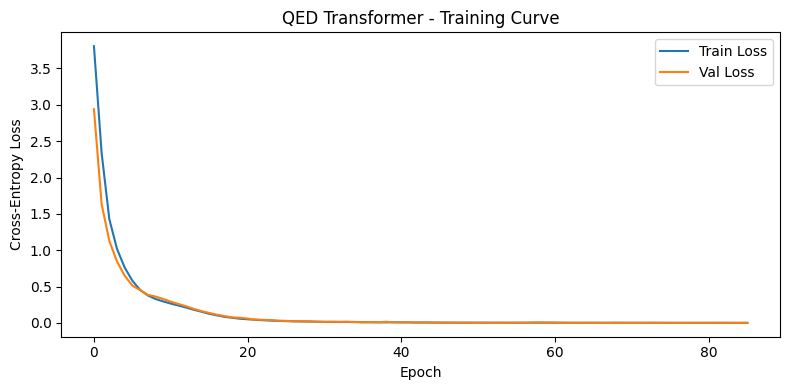

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(qed_history['train_loss'], label='Train Loss')
plt.plot(qed_history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('QED Transformer - Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

# QCD Baseline

In [29]:
qcd_cfg = Config(
    vocab_size   = len(vocab),
    dim          = 256, 
    heads        = 4,    
    enc_depth    = 3,      
    dec_depth    = 3, 
    ff_expansion = 4.0,
    dropout      = 0.1,
    pad_idx      = vocab.pad_idx,
    tie_weights  = False,
)

model_qcd = Transformer(qcd_cfg).to(device)
print(f'QCD Transformer parameters: {sum(p.numel() for p in model_qcd.parameters()):,}')
print(f'QCD Config: dim={qcd_cfg.dim}, heads={qcd_cfg.heads}, '
      f'enc_depth={qcd_cfg.enc_depth}, dec_depth={qcd_cfg.dec_depth}')

QCD Transformer parameters: 5,711,360
QCD Config: dim=256, heads=4, enc_depth=3, dec_depth=3


In [30]:
QCD_EPOCHS    = 250
QCD_GRAD_CLIP = 1.0
QCD_PATIENCE  = 20
QCD_MIN_DELTA = 1e-3
QCD_RUN_DIR   = 'plain_qcd_run'

qcd_optimizer = torch.optim.AdamW(model_qcd.parameters(), lr=1e-4, weight_decay=0.01)
qcd_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(qcd_optimizer, T_max=QCD_EPOCHS)
qcd_history   = {'train_loss': [], 'val_loss': []}

best_val_qcd   = float('inf')
no_improve_qcd = 0

for epoch in range(1, QCD_EPOCHS + 1):
    tl = run_epoch(model_qcd, qcd_optimizer, train_loader_qcd, device,
                   grad_clip=QCD_GRAD_CLIP, train=True)
    vl = run_epoch(model_qcd, qcd_optimizer, val_loader_qcd, device, train=False)
    qcd_scheduler.step()

    qcd_history['train_loss'].append(tl)
    qcd_history['val_loss'].append(vl)

    improved = vl < best_val_qcd - QCD_MIN_DELTA
    marker   = ' *' if improved else ''
    print(f'[QCD] Epoch {epoch:3d} | train={tl:.4f}  val={vl:.4f}{marker}')

    if improved:
        best_val_qcd   = vl
        no_improve_qcd = 0
        model_qcd.save_artifacts(QCD_RUN_DIR, vocab, tok, qcd_optimizer, qcd_scheduler, qcd_history)
        print(f'           Saved to {QCD_RUN_DIR}/')
    else:
        no_improve_qcd += 1
        if no_improve_qcd >= QCD_PATIENCE:
            print(f'[QCD] Early stopping after {QCD_PATIENCE} epochs without improvement.')
            break

print(f'\n[QCD] Training done. Best val loss: {best_val_qcd:.4f}')

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

[QCD] Epoch   1 | train=4.7663  val=3.8763 *
           Saved to plain_qcd_run/


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

[QCD] Epoch 243 | train=0.1142  val=0.0511


  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

[QCD] Epoch 244 | train=0.1203  val=0.0511
[QCD] Early stopping after 20 epochs without improvement.

[QCD] Training done. Best val loss: 0.0514


In [31]:
model_qcd_best, _, _, _ = Transformer.load_artifacts(QCD_RUN_DIR, device=device)
model_qcd_best = model_qcd_best.to(device)

qcd_val_seq_acc, qcd_val_tok_acc = seq_acc_ar(
    model_qcd_best, vocab, val_loader_qcd, device, n_batches=50
)
qcd_history['val_seq_acc']     = qcd_val_seq_acc
qcd_history['val_tok_acc_ar']  = qcd_val_tok_acc

print(f'[QCD] Val sequence accuracy (AR): {qcd_val_seq_acc:.4f}')
print(f'[QCD] Val token accuracy    (AR): {qcd_val_tok_acc:.4f}')

[QCD] Val sequence accuracy (AR): 0.3043
[QCD] Val token accuracy    (AR): 0.3907


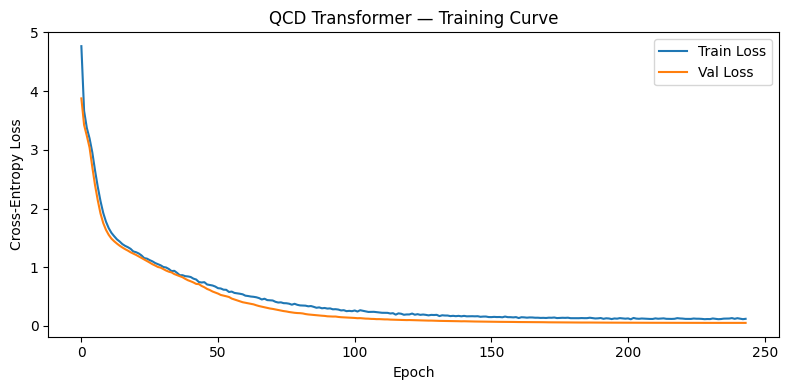

In [32]:
plt.figure(figsize=(8, 4))
plt.plot(qcd_history['train_loss'], label='Train Loss')
plt.plot(qcd_history['val_loss'],   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('QCD Transformer — Training Curve')
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation

In [33]:
# QED test accuracy
print("\nEvaluating QED on test set ...")
qed_test_seq_acc, qed_test_tok_acc = seq_acc_ar(
    model_qed_best, vocab, test_loader_qed, device, n_batches=len(test_loader_qed)
)
print(f'[QED] Test sequence accuracy (AR): {qed_test_seq_acc:.4f}')
print(f'[QED] Test token accuracy    (AR): {qed_test_tok_acc:.4f}')

# QCD test accuracy
print("\nEvaluating QCD on test set ...")
qcd_test_seq_acc, qcd_test_tok_acc = seq_acc_ar(
    model_qcd_best, vocab, test_loader_qcd, device, n_batches=len(test_loader_qcd)
)
print(f'[QCD] Test sequence accuracy (AR): {qcd_test_seq_acc:.4f}')
print(f'[QCD] Test token accuracy    (AR): {qcd_test_tok_acc:.4f}')


Evaluating QED on test set ...
[QED] Test sequence accuracy (AR): 0.9722
[QED] Test token accuracy    (AR): 0.9997

Evaluating QCD on test set ...
[QCD] Test sequence accuracy (AR): 0.6667
[QCD] Test token accuracy    (AR): 0.8386
